# Simulating the role of extrusion rate on higher-order chromatin folding 

This notebook showcases how to set up and visualize (block) copolymer simulations of mESC chromosomes with quantitatively-parametrized levels of cohesin extrusion activity.

The workflow closely follows the protocol highlighted in [Shah et al. (2026)](https://www.biorxiv.org/content/10.1101/2025.08.14.667581v2).
Note that for computational tractability, the lengths of the simulations illustrated below are reduced ~100 fold relative to those employed in the paper.

In [1]:
import os
import json
import hoomd
import codecs

import numpy as np

import polychrom_hoomd.log as log
import polychrom_hoomd.build as build
import polychrom_hoomd.forces as forces
import polychrom_hoomd.render as render
import polychrom_hoomd.extrude as extrude

from polykit.generators.initial_conformations import grow_cubic
from onestate_extruder import LEFTranslocatorDirectional, compute_LEF_pos

In [2]:
# Initialise HooMD on the CPU or GPU, based on availability
hoomd_device = build.get_hoomd_device()

HOOMD is running on the following GPU(s):
[0]           NVIDIA L40S 142 SM_8.9 @ 2.52 GHz, 45457 MiB DRAM


In [3]:
# Generate RNG seed
rng_seed = os.urandom(2)
rng_seed = int(codecs.encode(rng_seed, 'hex'), 16)

print("Using entropy-harvested random seed: %d" % rng_seed)

Using entropy-harvested random seed: 37756


In [4]:
# Initialize empty simulation object
system = hoomd.Simulation(device=hoomd_device, seed=rng_seed)

In [5]:
# Simulate 10 chromosome copies at fixed 0.2 number density
density = 0.2
n_copies = 10

In [6]:
# Simulate 50Mb central region of mouse chromosome 2
id1 = 26425
id2 = 46425

chromatin_types = np.genfromtxt('mESC_chr2_2.5kb.dat')[id1:id2]
chromatin_types = np.tile(chromatin_types, n_copies)

chromosome_sizes = [len(chromatin_types)]

In [7]:
# Initialize simulation with the appropriate box size 
number_of_monomers = sum(chromosome_sizes)
L = (number_of_monomers/density) ** (1/3.)

snapshot = build.get_simulation_box(box_length=L)

In [8]:
# Build random, dense initial conformations
monomer_positions = grow_cubic(N=number_of_monomers, boxSize=int(L-1))

In [9]:
# Setup neighbor list
nl = hoomd.md.nlist.Cell(buffer=0.4)

In [10]:
# Read input force parameters
with open("force_dict_full.json", 'r') as dict_file:
    force_dict = json.load(dict_file)

In [11]:
# Parse particle/bond types
bond_types = force_dict['Bonded forces'].keys()
angle_types = force_dict['Angular forces'].keys()
monomer_types = force_dict['Non-bonded forces']['Attraction']['Matrix'].keys()

In [12]:
# Populate snapshot with the generated chains
build.set_chromosomes(snapshot, monomer_positions, chromosome_sizes, 
                      bond_type_list=list(bond_types), monomer_type_list=list(monomer_types),
                      angle_type_list=list(angle_types))

snapshot.particles.typeid[:] = chromatin_types

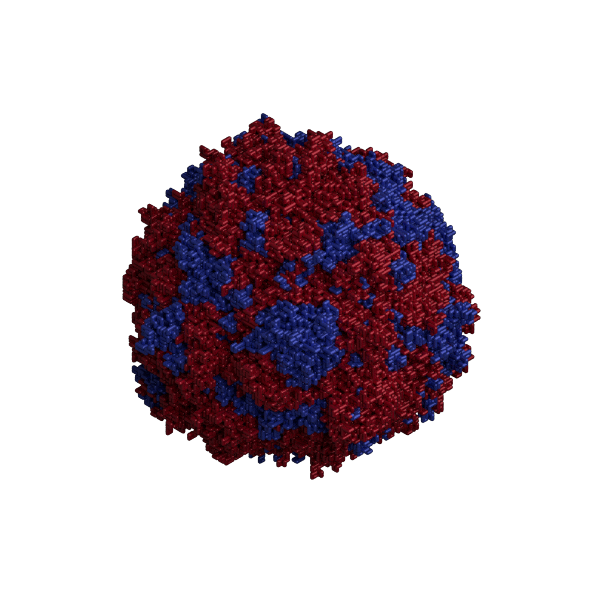

In [13]:
# Visualize starting conformation using the Fresnel backend (A compartments in blue, B in red)
render.fresnel(snapshot, show='compartments', cmap="coolwarm").static(pathtrace=True)

In [14]:
# Setup HooMD simulation object
system.create_state_from_snapshot(snapshot)

In [15]:
# Set chromosome excluded volume
repulsion_forces = forces.get_repulsion_forces(nl, **force_dict)

In [16]:
# Set bonded/angular potentials
bonded_forces = forces.get_bonded_forces(**force_dict)
angular_forces = forces.get_angular_forces(**force_dict)

In [17]:
# Set B-B attraction strength of .05 kT
epsilon = 0.05

force_dict['Non-bonded forces']['Attraction']['Matrix']['B']['B'] = epsilon

In [18]:
# Set attractive/DPD forces
dpd_forces = forces.get_dpd_forces(nl, **force_dict)
attraction_forces = forces.get_attraction_forces(nl, **force_dict)

Setting up DPD with the conservative force contribution disabled


In [19]:
# Define full force_field
dpd_force_field = repulsion_forces + bonded_forces + angular_forces \
             + attraction_forces + dpd_forces

In [20]:
# Setup integrator methods
nve = hoomd.md.methods.NVE(filter=hoomd.filter.All())
dpd_integrator = hoomd.md.Integrator(dt=5e-3, methods=[nve], forces=dpd_force_field)

/home1/tortora/.conda/envs/multistate/lib/python3.10/site-packages/hoomd/md/methods/methods.py:699: FutureWarning: NVE is deprecated and wil be removed in hoomd 4.0. In version 4.0, use the ConstantVolume method without a thermostat.
  warnings.warn(


In [21]:
# Set up logs and integrator objects
logger = log.get_logger(system)

system.operations.integrator = dpd_integrator
system.operations.writers.append(log.table_formatter(logger, period=1000))

In [22]:
# Run
system.run(1e5)

Simulation.timestep  Simulation.tps     Status.etr    Thermo.kinetic_temperature
       1000            225.04663      0:07:19.908829           0.94112          
       2000            322.21781      0:05:04.142093           1.19004          
       3000            393.90810      0:04:06.250332           1.23854          
       4000            447.03287      0:03:34.749311           1.22108          
       5000            486.82050      0:03:15.143797           1.18654          
       6000            516.18537      0:03:02.105124           1.14011          
       7000            536.40388      0:02:53.376821           1.08530          
       8000            550.75622      0:02:47.043051           1.04815          
       9000            563.15573      0:02:41.589405           1.03079          
       10000           574.97508      0:02:36.528524           1.02755          
       11000           586.68752      0:02:31.699153           1.03062          
       12000           598.5

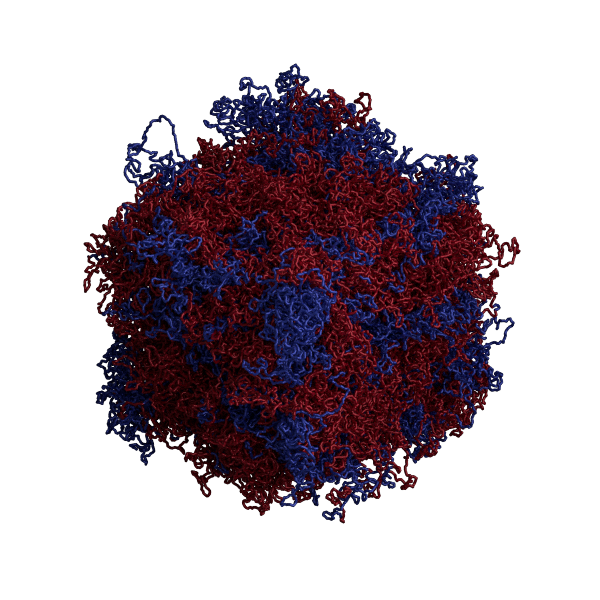

In [23]:
# Visualize new conformation
snapshot_relaxed = system.state.get_snapshot()
render.fresnel(snapshot_relaxed, show='compartments', cmap="coolwarm").static(pathtrace=True)

In [24]:
# Parse extrusion parameters
with open("onestate_extrusion_dict.json", 'r') as dict_file:
    extrusion_dict = json.load(dict_file)

In [25]:
# Lattice and polymer time units (in seconds)
tau_1d = 20 # [s], yields a baseline extrusion rate of 2*2.5/20 = 0.25 kb/s
tau_3d = 0.005 # [s], from fitting polymer kinetics to experimental MSDs

In [26]:
# Rescale baseline velocity to 1 kb/s
velocity_multiplier = 4

tau_1d_rescaled = tau_1d / velocity_multiplier
n_3d_to_1d = tau_1d_rescaled / tau_3d

In [27]:
# Convert residence times from seconds to lattice units
extrusion_dict["LEF_lifetime"] /= tau_1d_rescaled

In [28]:
# Precompute 1D loop extrusion trajectory
lef_trajectory = compute_LEF_pos(LEFTranslocatorDirectional, len(chromatin_types), **extrusion_dict)

In [29]:
# Run 3D simulation
for lef_positions in lef_trajectory:
    extrude.update_topology(system, lef_positions, thermalize=False)
    system.run(n_3d_to_1d)

/home1/tortora/polychrom-hoomd/polychrom_hoomd/extrude.py:39: UserWarning: name 'cd' is not defined - Reverting to non-local topology update
  warnings.warn("%s - Reverting to non-local topology update" % e)


      101000           433.46751         0:00:00               8.26352          
      102000           489.35182         0:00:00               5.87269          
      103000           592.80129         0:00:00               4.62860          
      104000           661.94054         0:00:00               3.88170          
      105000           688.20801         0:00:00               3.39098          
      106000           706.41444         0:00:00               3.04502          
      107000           717.96073         0:00:00               2.78498          
      108000           726.01850         0:00:00               2.58059          
      109000           731.61193         0:00:00               2.42155          
      110000           733.64339         0:00:00               2.28528          
      111000           739.08190         0:00:00               2.16971          
      112000           744.67102         0:00:00               2.08076          
      113000           747.1

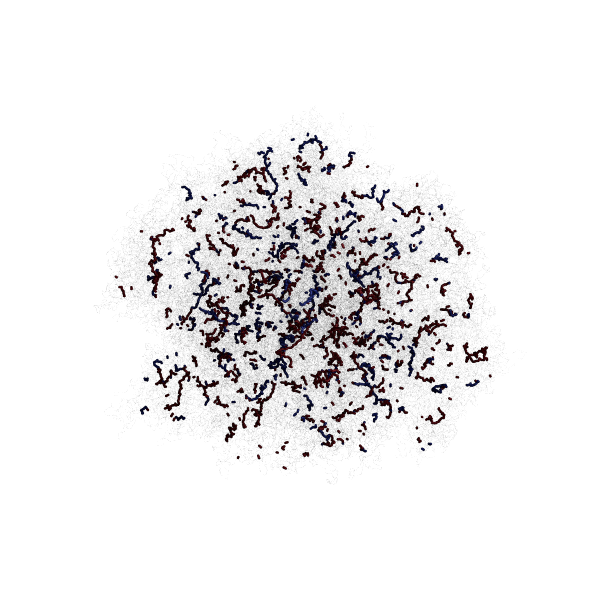

In [30]:
# Visualize new conformation, highlighting extruder positions
snapshot_final = system.state.get_snapshot()
render.fresnel(snapshot_final, show="compartments", cmap="coolwarm", rescale_backbone_bonds=0.05).static(pathtrace=True)